In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo
df = pd.read_csv("06. videojuegos.csv")

In [3]:
# Inspección del DataFrame
print("--- Primeras 5 filas ---")
display(df.head())

print("\n--- Últimas 5 filas ---")
display(df.tail())

print("\n--- Información General ---")
df.info()

print("\n--- Dimensiones ---")
print(f"El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

--- Primeras 5 filas ---


,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.516229,8.243746,1.860090,NaN
1,Juego_1,Nintendo,2019,Acción,9.533212,3.665887,3.882065,97.0
2,Juego_2,PC,2021,Aventura,5.151544,1.357899,1.704018,67.0
3,Juego_3,Xbox,2011,Estrategia,5.303223,5.270208,4.653787,75.0
4,Juego_4,Xbox,2019,Estrategia,10.916740,7.722936,4.292064,65.0



--- Últimas 5 filas ---


,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
95,Juego_95,PlayStation,2012,Acción,8.185405,1.856651,1.404816,88.0
96,Juego_96,PlayStation,2015,RPG,4.369465,7.531086,4.752057,79.0
97,Juego_97,Nintendo,2021,Acción,8.903416,8.087664,4.451319,71.0
98,Juego_98,PlayStation,2011,Estrategia,0.554454,9.906001,2.278284,73.0
99,Juego_99,PC,2019,Aventura,0.656488,4.184915,3.100663,67.0



--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nombre            100 non-null    str    
 1   Plataforma        100 non-null    str    
 2   Anio_Lanzamiento  100 non-null    int64  
 3   Genero            100 non-null    str    
 4   Ventas_NA         100 non-null    float64
 5   Ventas_EU         100 non-null    float64
 6   Ventas_JP         100 non-null    float64
 7   Critica_Puntaje   90 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 6.4 KB

--- Dimensiones ---
El DataFrame tiene 100 filas y 8 columnas.


In [4]:
# Calcular medidas de tendencia central y dispersión
cols_num = ['Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje']
desc = df[cols_num].describe().loc[['mean', '50%', 'std', 'min', 'max']]
desc.loc['rango'] = desc.loc['max'] - desc.loc['min']
desc = desc.rename(index={'50%': 'mediana', 'mean': 'media', 'std': 'desviación estándar'})
display(desc)

,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
media,8.108120,4.795395,2.645642,68.700000
mediana,8.706121,5.024023,2.758458,68.500000
desviación estándar,4.359312,2.901882,1.568193,17.873117
min,0.175418,0.242496,0.054188,40.000000
max,14.851802,9.906001,4.964824,99.000000
rango,14.676385,9.663505,4.910636,59.000000


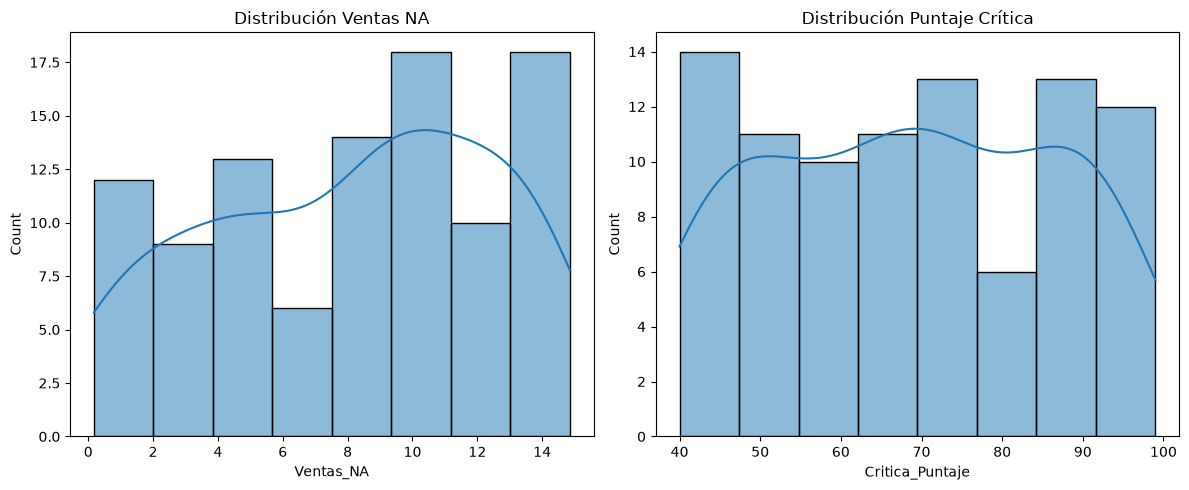

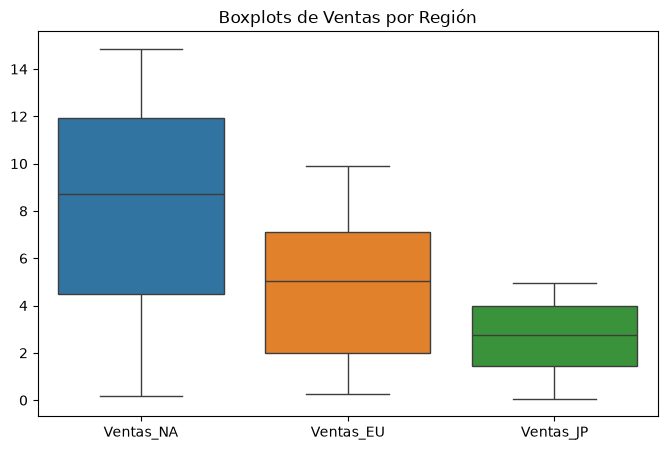

In [5]:
# histogramas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Ventas_NA'], kde=True)
plt.title('Distribución Ventas NA')

plt.subplot(1, 2, 2)
sns.histplot(df['Critica_Puntaje'].dropna(), kde=True)
plt.title('Distribución Puntaje Crítica')
plt.tight_layout()
plt.show()

# boxplots
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['Ventas_NA', 'Ventas_EU', 'Ventas_JP']])
plt.title('Boxplots de Ventas por Región')
plt.show()

--- Frecuencia por Plataforma ---
Plataforma
Nintendo       30
PlayStation    26
Xbox           24
PC             20
Name: count, dtype: int64

--- Frecuencia por Género ---
Genero
Acción        29
Estrategia    26
Deportes      20
RPG           15
Aventura      10
Name: count, dtype: int64


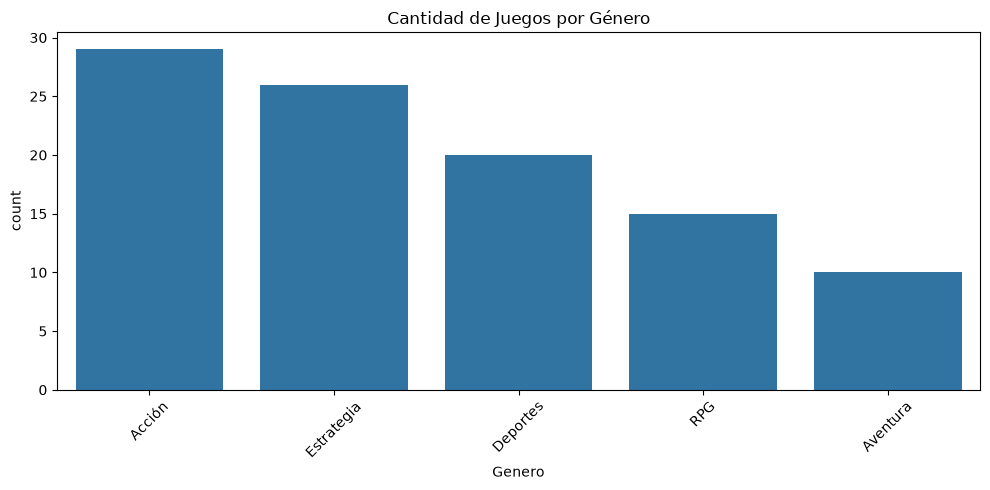

In [6]:
# Tablas de frecuencia
print("--- Frecuencia por Plataforma ---")
print(df['Plataforma'].value_counts())

print("\n--- Frecuencia por Género ---")
print(df['Genero'].value_counts())

# Gráfico de barras por Género
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Genero', order=df['Genero'].value_counts().index)
plt.title('Cantidad de Juegos por Género')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()